In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [16]:
PATH_TO_DATA = "data/house_price"
df = pd.read_csv(f"../{PATH_TO_DATA}/train.csv")

In [17]:
df.shape

(924, 8)

In [18]:
df.head()

,Unnamed: 0,Address,Zip,Price,Area,Room,Lon,Lat
0,1,"Blasiusstraat 8 2, Amsterdam",1091 CR,685000.0,64,3,4.907736,52.356157
1,2,"Kromme Leimuidenstraat 13 H, Amsterdam",1059 EL,475000.0,60,3,4.850476,52.348586
2,3,"Zaaiersweg 11 A, Amsterdam",1097 SM,850000.0,109,4,4.944774,52.343782
3,4,"Tenerifestraat 40, Amsterdam",1060 TH,580000.0,128,6,4.789928,52.343712
4,5,"Winterjanpad 21, Amsterdam",1036 KN,720000.0,138,5,4.902503,52.410538


In [19]:
df.isna().sum()

Unnamed: 0    0
Address       0
Zip           0
Price         4
Area          0
Room          0
Lon           0
Lat           0
dtype: int64

In [20]:
df = df.dropna(subset=['Price'])
df.isna().sum()

Unnamed: 0    0
Address       0
Zip           0
Price         0
Area          0
Room          0
Lon           0
Lat           0
dtype: int64

In [21]:
df.shape

(920, 8)

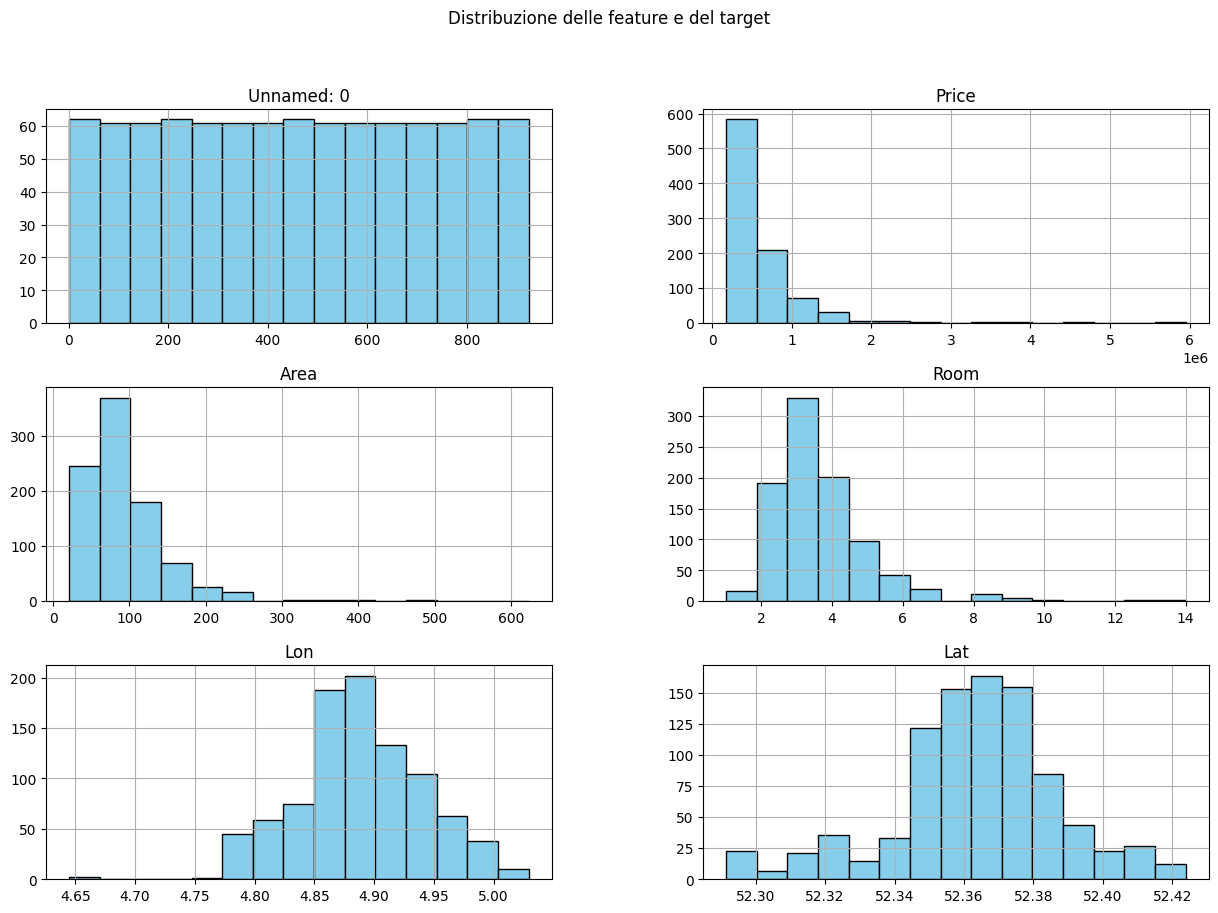

In [22]:
df.hist(bins=15, figsize=(15,10), color='skyblue', edgecolor='black')
plt.suptitle("Distribuzione delle feature e del target")
plt.show()

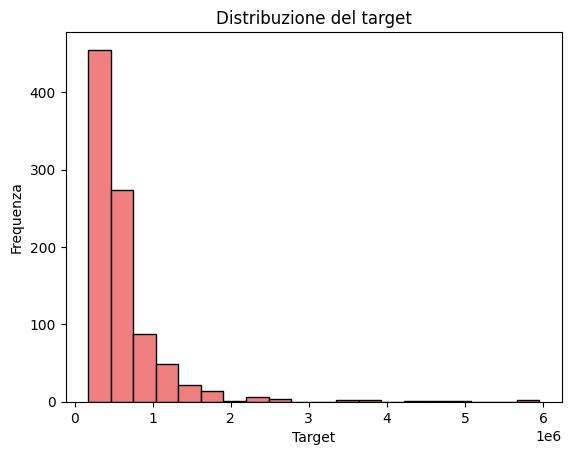

In [23]:
plt.hist(df['Price'], bins=20, color='lightcoral', edgecolor='black')
plt.title("Distribuzione del target")
plt.xlabel("Target")
plt.ylabel("Frequenza")
plt.show()

In [24]:
features = ["Area", "Room", "Price"]
df = df[features]

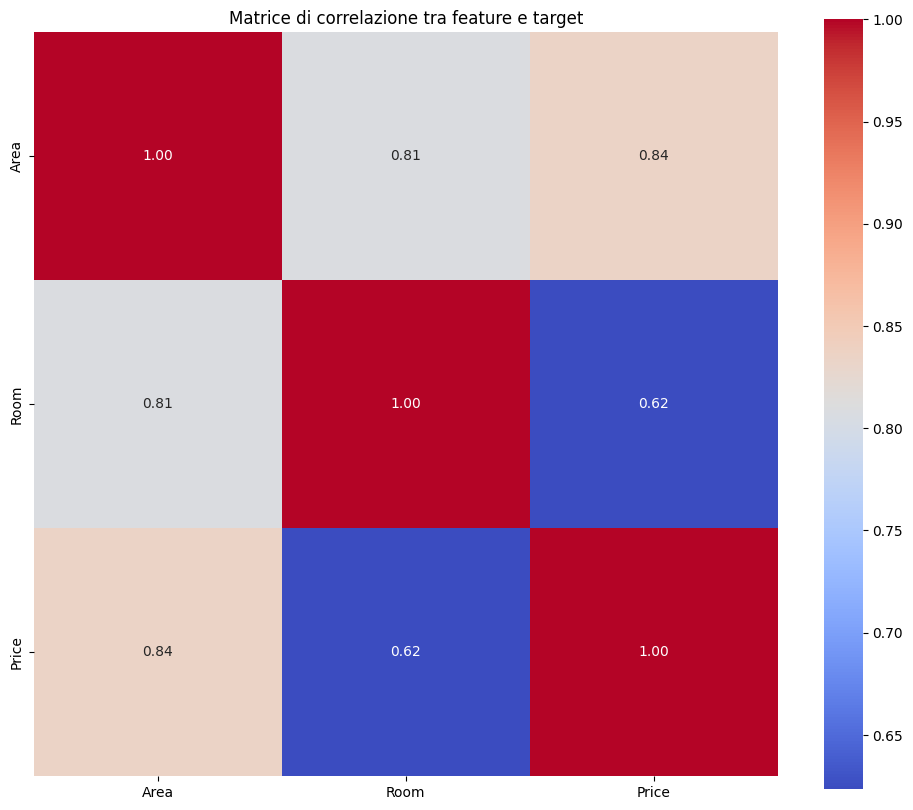

In [25]:
plt.figure(figsize=(12,10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Matrice di correlazione tra feature e target")
plt.show()

In [26]:
X = df[['Area']]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
reg_log_model = LinearRegression()
reg_log_model.fit(X_train, y_train)
y_pred = reg_log_model.predict(X_test)

In [28]:
print(f"Coefficiente: {reg_log_model.coef_[0]:.4f}, Intercetta: {reg_log_model.intercept_:.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²: {r2_score(y_test, y_pred):.2f}")

Coefficiente: 7869.1522, Intercetta: -129456.14
MSE: 67493869060.28
R²: 0.78
